# Prévision directe globale — Perleberg

Le notebook construit une prévision ponctuelle puis probabiliste de la production solaire. Une ligne représente un quart d'heure de livraison : une journée normale contient donc 96 lignes et `model.predict(X_demain)` retourne 96 valeurs.

## Les données du modèle

La météo réanalysée ERA5 et la production virtuelle sont transformés en mémoire. Les six statistiques glissantes utilisent uniquement de la production disponible jusqu'à `t−48 h` ; elles sont donc disponibles pour tous les quarts d'heure de demain.

In [1]:
from pathlib import Path
import sys


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
PROJECT_ROOT = next(
    folder for folder in [PROJECT_ROOT, *PROJECT_ROOT.parents]
    if (folder / 'config' / 'assets.yaml').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_assets
from src.features.solar import (
    build_solar_forecast_frame,
    build_solar_training_frame,
    solar_feature_columns,
)
from src.modeling.common import (
    build_candidate_models,
    fit_quantile_models,
    group_feature_contributions,
    grouped_permutation_importance,
    lightgbm_feature_contributions,
    pinball_loss,
)
from src.modeling.solar import (
    apply_conformal_adjustment,
    apply_solar_constraints,
    conformal_interval_adjustment,
    evaluate_candidate_models,
    hourly_error_profile,
    predict_ordered_quantiles,
    probabilistic_forecast_metrics,
    solar_regression_metrics,
)

# Charger le contrat métier du site : capacité, fuseau et météo autorisée.
site_config = load_assets(PROJECT_ROOT / 'config' / 'assets.yaml')['perleberg']
site_capacity_mw = float(site_config['capacity_mw'])
market_timezone = site_config['market_timezone']
# Lire la météo réanalysée ERA5 et la production virtuelle du site.
historical_data = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'asset_data' / 'perleberg_historical_reanalysis_15m.parquet'
)
historical_data['timestamp'] = pd.to_datetime(historical_data['timestamp'], utc=True)
# Construire les variables calendrier, soleil, lags et rollings sûrs à J-1.
model_data = build_solar_training_frame(historical_data, site_config)
predictor_columns = solar_feature_columns(site_config)
missing_history_rows = model_data[predictor_columns].isna().any(axis=1).sum()
model_data = model_data.dropna(subset=predictor_columns + ['production_mw']).copy()
study_end = pd.Timestamp('2026-09-01', tz=market_timezone)
local_time = model_data['timestamp'].dt.tz_convert(market_timezone)
outside_rows = (local_time >= study_end).sum()
model_data = model_data.loc[local_time < study_end].copy()
pd.DataFrame({
    'usable_rows': [len(model_data)],
    'rows_without_history': [missing_history_rows],
    'rows_after_august': [outside_rows],
    'predictors': [len(predictor_columns)],
    'target': ['production_mw'],
    'horizon_included': [False],
})

,usable_rows,rows_without_history,rows_after_august,predictors,target,horizon_included
0,92824,672,104,27,production_mw,False


Le jeu exploitable contient **92 824 quarts d'heure** et **27 prédicteurs**. Les 672 premières lignes n'ont pas encore sept jours d'historique ; 104 lignes après le 31 août local restent hors étude.

---
## Le dictionnaire des variables

La liste montre les prédicteurs réellement envoyés aux modèles. La direction du vent brute est remplacée par sinus/cosinus et la cible `production_mw` n'apparaît jamais parmi les entrées contemporaines.

In [2]:
pd.Series(predictor_columns, name='feature')

0                               temperature_2m
1                         relative_humidity_2m
2                               wind_speed_10m
3                                  cloud_cover
4                                precipitation
5                          shortwave_radiation
6                             direct_radiation
7                            diffuse_radiation
8                     direct_normal_irradiance
9                       wind_direction_10m_sin
10                      wind_direction_10m_cos
11                              local_time_sin
12                              local_time_cos
13                             day_of_year_sin
14                             day_of_year_cos
15                         solar_elevation_deg
16                           solar_azimuth_sin
17                           solar_azimuth_cos
18                                      is_day
19                       production_lag_48h_mw
20                        production_lag_7d_mw
21        pro

Les 27 variables se répartissent entre météo, géométrie solaire, calendrier et production déjà connue. 

---
## Séparation des périodes dans l'ordre du temps pour le modelling

Les frontières suivent l'heure de Berlin. Je compare les configurations sur janvier–février, mars–avril et mai 2026. À chaque passage, l'entraînement utilise tout le passé antérieur à la validation.

Juin sert à calibrer les intervalles avec la météo J-1. Juillet–août est le test final avec cette même information disponible avant le cutoff. Les bornes de fin sont exclues ; les jours de changement d'heure gardent leurs 92 ou 100 quarts d'heure.

In [3]:
validation_windows = pd.DataFrame([
    {'fold': 'janvier_fevrier', 'start_local': '2026-01-01', 'end_local': '2026-03-01'},
    {'fold': 'mars_avril', 'start_local': '2026-03-01', 'end_local': '2026-05-01'},
    {'fold': 'mai', 'start_local': '2026-05-01', 'end_local': '2026-06-01'},
])

local_time = model_data['timestamp'].dt.tz_convert(market_timezone)
calibration_start = pd.Timestamp('2026-06-01', tz=market_timezone)
test_start = pd.Timestamp('2026-07-01', tz=market_timezone)
train_final_rows = local_time < calibration_start
# Entraînement final : toutes les données disponibles jusqu'au 31 mai.
X_train_final = model_data.loc[train_final_rows, predictor_columns]
y_train_final = model_data.loc[train_final_rows, 'production_mw']

# Juin et juillet-août utilisent la météo J-1 disponible avant le cutoff.
j1_weather = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'asset_data' / 'perleberg_j1_forecast_weather_15m.parquet'
)
j1_weather['timestamp'] = pd.to_datetime(j1_weather['timestamp'], utc=True)
j1_features = build_solar_forecast_frame(j1_weather, historical_data, site_config)
actual_generation = historical_data[['timestamp', 'production_mw']]
operational_data = j1_features.merge(actual_generation, on='timestamp', how='inner')
operational_time = operational_data['timestamp'].dt.tz_convert(market_timezone)
calibration_data = operational_data.loc[
    (operational_time >= calibration_start) & (operational_time < test_start)
].copy()
test_data = operational_data.loc[
    (operational_time >= test_start) & (operational_time < study_end)
].copy()
X_calibration = calibration_data[predictor_columns]
y_calibration = calibration_data['production_mw']
X_test = test_data[predictor_columns]
y_test = test_data['production_mw']
calibration_timestamps = calibration_data['timestamp']
calibration_is_day = X_calibration['is_day']
test_timestamps = test_data['timestamp']
test_is_day = X_test['is_day']

# Garder les indices de chaque passage pour réutiliser exactement les mêmes lignes.
fold_rows = {}
partition_records = []
for window in validation_windows.itertuples(index=False):
    start = pd.Timestamp(window.start_local, tz=market_timezone)
    end = pd.Timestamp(window.end_local, tz=market_timezone)
    train_rows = local_time < start
    validation_rows = (local_time >= start) & (local_time < end)
    fold_rows[window.fold] = (train_rows, validation_rows)
    for role, rows in [('train', train_rows), ('validation', validation_rows)]:
        dates = local_time.loc[rows]
        partition_records.append({
            'passage': window.fold, 'usage': role, 'lignes': int(rows.sum()),
            'debut_local': dates.min(), 'fin_locale': dates.max(),
        })

for role, frame in [('calibration', calibration_data), ('test', test_data)]:
    dates = frame['timestamp'].dt.tz_convert(market_timezone)
    partition_records.append({
        'passage': 'final', 'usage': role, 'lignes': len(frame),
        'debut_local': dates.min(), 'fin_locale': dates.max(),
    })
display(pd.DataFrame(partition_records))

assert model_data.loc[train_final_rows, 'timestamp'].max() < calibration_timestamps.min()
assert calibration_timestamps.max() < test_timestamps.min()
assert len(X_calibration) == 29 * 96  # Le 12 juin est indisponible dans l'archive.
assert len(X_test) == 62 * 96


,passage,usage,lignes,debut_local,fin_locale
0,janvier_fevrier,train,69500,2024-01-08 01:00:00+01:00,2025-12-31 23:45:00+01:00
1,janvier_fevrier,validation,5664,2026-01-01 00:00:00+01:00,2026-02-28 23:45:00+01:00
2,mars_avril,train,75164,2024-01-08 01:00:00+01:00,2026-02-28 23:45:00+01:00
3,mars_avril,validation,5852,2026-03-01 00:00:00+01:00,2026-04-30 23:45:00+02:00
4,mai,train,81016,2024-01-08 01:00:00+01:00,2026-04-30 23:45:00+02:00
5,mai,validation,2976,2026-05-01 00:00:00+02:00,2026-05-31 23:45:00+02:00
6,final,calibration,2784,2026-06-01 00:00:00+02:00,2026-06-30 23:45:00+02:00
7,final,test,5952,2026-07-01 00:00:00+02:00,2026-08-31 23:45:00+02:00



---
## Baseline : Persistance

La persistance copie la production du même quart d'heure deux jours plus tôt. Elle donne le niveau minimal que les modèles utilisant la météo de la cible doivent dépasser.

Je regarde la MAE globale et la MAE sur les heures éclairées : les zéros nocturnes réduisent mécaniquement la première. Pour l'énergie journalière, chaque puissance en MW est multipliée par 0,25 h avant la somme par jour.

In [4]:
baseline_records = []
for fold, (_, validation_rows) in fold_rows.items():
    validation = model_data.loc[validation_rows]
    persistence = apply_solar_constraints(
        validation['production_lag_48h_mw'], validation['is_day'], site_capacity_mw
    )
    baseline_records.append({
        'family': 'Persistence 48h', 'configuration': 'fixed',
        'fold': fold, 'fit_seconds': 0.0,
        **solar_regression_metrics(
            validation['production_mw'], persistence,
            validation['timestamp'], validation['is_day'],
            capacity_mw=site_capacity_mw, market_timezone=market_timezone,
        ),
    })

baseline_results = pd.DataFrame(baseline_records)
display(baseline_results[[
    'fold', 'mae_mw', 'daylight_mae_mw', 'rmse_mw',
    'bias_mw', 'daily_energy_mae_mwh',
]].round(4))


,fold,mae_mw,daylight_mae_mw,rmse_mw,bias_mw,daily_energy_mae_mwh
0,janvier_fevrier,0.8684,2.3312,2.0239,-0.0764,19.9021
1,mars_avril,1.3430,2.5021,2.8693,-0.0814,28.7060
2,mai,1.5382,2.3391,3.1459,0.1440,31.5642



---
## Phase de sélection des modèles sur la validation

Je teste les neuf configurations de Ridge, HistGradientBoosting, XGBoost et LightGBM sur les trois mêmes fenêtres. La grille reste limitée : régularisation de Ridge, profondeur de XGBoost et nombre de feuilles pour les deux autres modèles.

Le classement utilise la MAE moyenne des trois fenêtres, avec le même poids pour chacune. La MAE de jour, la RMSE, le biais et la MAE d'énergie journalière complètent la lecture. L'écart-type entre fenêtres indique leur variabilité ; ce n'est pas un intervalle de confiance.

In [5]:
candidate_models = build_candidate_models(random_state=42)
fold_results = []

for fold, (train_rows, validation_rows) in fold_rows.items():
    # Un nouveau modèle par configuration et par passage, scaler compris.
    fresh_models = {
        family: {name: clone(model) for name, model in configurations.items()}
        for family, configurations in candidate_models.items()
    }
    scores, _ = evaluate_candidate_models(
        fresh_models,
        model_data.loc[train_rows, predictor_columns],
        model_data.loc[train_rows, 'production_mw'],
        model_data.loc[validation_rows, predictor_columns],
        model_data.loc[validation_rows, 'production_mw'],
        model_data.loc[validation_rows, 'timestamp'],
        model_data.loc[validation_rows, 'is_day'],
        capacity_mw=site_capacity_mw, market_timezone=market_timezone,
    )
    scores['fold'] = fold
    fold_results.append(scores)

cv_results = pd.concat([*fold_results, baseline_results], ignore_index=True)
candidate_results = (
    cv_results.groupby(['family', 'configuration'], as_index=False)
    .agg(
        mae_mean_mw=('mae_mw', 'mean'),
        mae_std_mw=('mae_mw', 'std'),
        mae_worst_mw=('mae_mw', 'max'),
        daylight_mae_mean_mw=('daylight_mae_mw', 'mean'),
        rmse_mean_mw=('rmse_mw', 'mean'),
        bias_mean_mw=('bias_mw', 'mean'),
        nmae_capacity_mean_pct=('nmae_capacity_pct', 'mean'),
        daily_energy_mae_mean_mwh=('daily_energy_mae_mwh', 'mean'),
        fit_seconds_total=('fit_seconds', 'sum'),
    )
    .sort_values(['mae_mean_mw', 'mae_std_mw'], ignore_index=True)
)
display(candidate_results.round(5))
display(cv_results.pivot(
    index=['family', 'configuration'], columns='fold', values='mae_mw'
)[validation_windows['fold'].tolist()].round(5))


,family,configuration,mae_mean_mw,mae_std_mw,mae_worst_mw,daylight_mae_mean_mw,rmse_mean_mw,bias_mean_mw,nmae_capacity_mean_pct,daily_energy_mae_mean_mwh,fit_seconds_total
0,LightGBM,leaves_63,0.04371,0.01518,0.05550,0.08312,0.08813,-0.00489,0.19779,0.55849,7.76843
1,XGBoost,depth_6,0.04772,0.01610,0.06161,0.09127,0.09427,-0.00762,0.21593,0.56994,10.85901
2,LightGBM,leaves_31,0.05015,0.01537,0.05951,0.09563,0.09711,-0.00593,0.22695,0.59724,5.87388
3,HistGradientBoosting,leaves_31,0.05511,0.01819,0.06670,0.10465,0.10554,-0.00764,0.24935,0.61847,8.73409
4,XGBoost,depth_4,0.06655,0.02015,0.07911,0.12703,0.12558,-0.00596,0.30112,0.64874,7.06844
5,HistGradientBoosting,leaves_15,0.06826,0.02234,0.08214,0.12944,0.12871,-0.00717,0.30888,0.74457,8.63306
6,Ridge,alpha_1,0.32349,0.10553,0.42805,0.61325,0.61966,0.04795,1.46377,5.42123,0.28535
7,Ridge,alpha_10,0.32374,0.10556,0.42832,0.61375,0.62028,0.04818,1.46490,5.42828,0.24809
8,Ridge,alpha_100,0.32578,0.10627,0.43097,0.61758,0.62526,0.04915,1.47412,5.48451,0.27920
9,Persistence 48h,fixed,1.24987,0.34446,1.53820,2.39081,2.67971,-0.00461,5.65554,26.72412,0.00000


fold                                janvier_fevrier  mars_avril      mai
family               configuration                                      
HistGradientBoosting leaves_15              0.04249     0.08016  0.08214
                     leaves_31              0.03414     0.06670  0.06448
LightGBM             leaves_31              0.03241     0.05951  0.05855
                     leaves_63              0.02658     0.05550  0.04906
Persistence 48h      fixed                  0.86842     1.34299  1.53820
Ridge                alpha_1                0.21701     0.32542  0.42805
                     alpha_10               0.21724     0.32567  0.42832
                     alpha_100              0.21846     0.32791  0.43097
XGBoost              depth_4                0.04331     0.07911  0.07723
                     depth_6                0.03007     0.06161  0.05148

LightGBM à 63 feuilles arrive en tête avec **0,0437 MW de MAE moyenne**, devant XGBoost à **0,0477 MW**. Il gagne sur chacune des trois fenêtres. La persistance atteint **1,2499 MW** en moyenne.

---
## Comparer une configuration par famille

La meilleure configuration de chaque famille est comparée à la persistance. La MAE mesure l'écart par quart d'heure ; la MAE d'énergie compare les totaux journaliers en MWh, avec compensation possible des erreurs à l'intérieur d'une journée.

Modèle ponctuel retenu : LightGBM / leaves_63
Configuration LightGBM pour les quantiles : leaves_63


,family,configuration,mae_mean_mw,mae_std_mw,mae_worst_mw,daylight_mae_mean_mw,rmse_mean_mw,bias_mean_mw,nmae_capacity_mean_pct,daily_energy_mae_mean_mwh,fit_seconds_total
0,LightGBM,leaves_63,0.043712,0.015184,0.055496,0.083116,0.088135,-0.004887,0.197794,0.558494,7.768428
1,XGBoost,depth_6,0.047722,0.016101,0.061611,0.091267,0.094270,-0.007618,0.215935,0.569944,10.859006
2,HistGradientBoosting,leaves_31,0.055106,0.018193,0.066701,0.104654,0.105535,-0.007640,0.249349,0.618474,8.734087
3,Ridge,alpha_1,0.323493,0.105533,0.428051,0.613252,0.619665,0.047950,1.463770,5.421227,0.285354
4,Persistence 48h,fixed,1.249873,0.344463,1.538203,2.390810,2.679713,-0.004607,5.655536,26.724118,0.000000


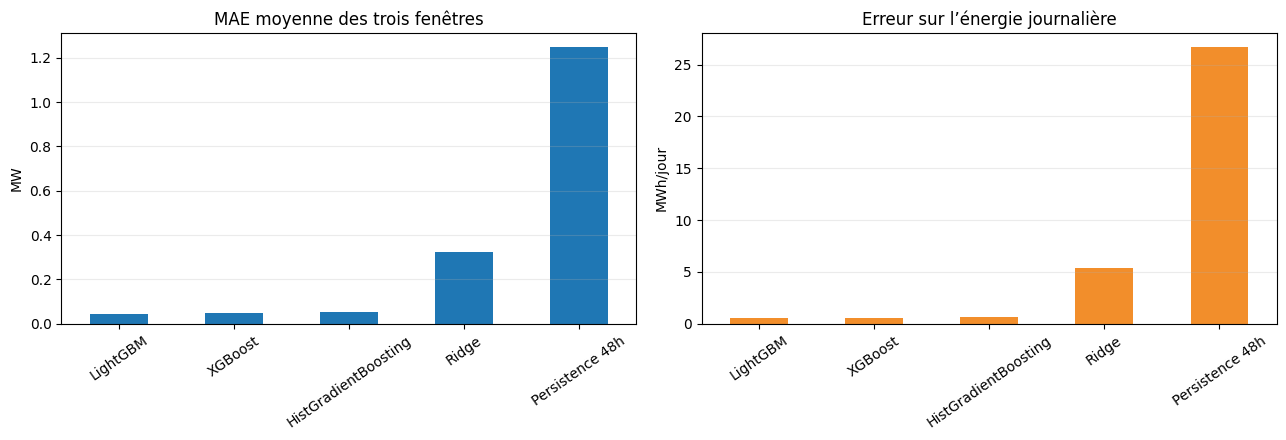

In [6]:
validation_comparison = candidate_results.drop_duplicates('family').reset_index(drop=True)
ml_validation_comparison = validation_comparison.loc[
    validation_comparison['family'] != 'Persistence 48h'
]
selected_model_row = ml_validation_comparison.iloc[0]
selected_family = selected_model_row['family']
selected_configuration = selected_model_row['configuration']

# Les quantiles reprendront les paramètres du meilleur LightGBM,
# même si une autre famille gagne la comparaison ponctuelle.
best_lightgbm_row = candidate_results.loc[
    candidate_results['family'] == 'LightGBM'
].iloc[0]
best_lightgbm_configuration = best_lightgbm_row['configuration']
print(f'Modèle ponctuel retenu : {selected_family} / {selected_configuration}')
print(f'Configuration LightGBM pour les quantiles : {best_lightgbm_configuration}')

display(validation_comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
validation_comparison.plot.bar(x='family', y='mae_mean_mw', ax=axes[0], legend=False)
validation_comparison.plot.bar(
    x='family', y='daily_energy_mae_mean_mwh', ax=axes[1], legend=False, color='#F28E2B'
)
axes[0].set(title='MAE moyenne des trois fenêtres', xlabel='', ylabel='MW')
axes[1].set(title='Erreur sur l’énergie journalière', xlabel='', ylabel='MWh/jour')
for axis in axes:
    axis.tick_params(axis='x', rotation=35)
    axis.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

LightGBM reste en tête sur la MAE de jour (**0,0831 MW**) et sur l'énergie journalière (**0,5585 MWh de MAE moyenne**). Sa configuration est maintenant figée ; je garde un modèle ponctuel séparé pour mesurer sa performance finale.

---

## Évaluation de la prévision ponctuelle finale

La meilleure famille ML est figée selon la validation, réentraînée sur toutes les données jusqu'au 31 mai, puis comparée à la persistance avec la météo J-1 sur le test.

In [7]:
final_point_model = clone(candidate_models[selected_family][selected_configuration])
final_point_model.fit(X_train_final, y_train_final)

test_point_prediction = apply_solar_constraints(
    final_point_model.predict(X_test), test_is_day, site_capacity_mw
)
test_persistence = apply_solar_constraints(
    X_test['production_lag_48h_mw'], test_is_day, site_capacity_mw
)
test_point_results = []
for model_name, prediction in [
    ('Persistence 48h', test_persistence),
    (selected_family, test_point_prediction),
]:
    test_point_results.append({
        'model': model_name,
        **solar_regression_metrics(
            y_test, prediction, test_timestamps, test_is_day,
            capacity_mw=site_capacity_mw, market_timezone=market_timezone,
        ),
    })
test_point_results = pd.DataFrame(test_point_results).sort_values('mae_mw')
print(f'Modèle sélectionné : {selected_family} / {selected_configuration}')
test_point_results

Modèle sélectionné : LightGBM / leaves_63


,model,mae_mw,rmse_mw,nmae_capacity_pct,bias_mw,daylight_mae_mw,daily_energy_mae_mwh,daily_energy_bias_mwh
1,LightGBM,0.983212,1.887766,4.448925,-0.091663,1.527161,12.726594,-2.199919
0,Persistence 48h,1.487684,2.851142,6.731601,0.010443,2.310724,29.276758,0.250632


Le tableau précédent compare P50 et la persistance avec les forecasts météo J-1. Il décrit donc l'erreur rencontrée au moment de la décision.

---
## Modelling de P10, P50 et P90

Je reprends les hyperparamètres du meilleur LightGBM de la validation ponctuelle pour entraîner trois nouveaux modèles à perte quantile : P10, P50 et P90. Ils utilisent les mêmes 27 prédicteurs et apprennent jusqu'à fin mai ; juin sert à calibrer leur intervalle avec les forecasts J-1.

Ces paramètres ont été choisis sur la MAE, pas sur des métriques probabilistes. Comparer plusieurs configurations quantiles par validation temporelle constituerait une étude supplémentaire.

In [8]:
best_lightgbm = candidate_models['LightGBM'][best_lightgbm_configuration]
quantile_levels = {'p10_mw': 0.10, 'p50_mw': 0.50, 'p90_mw': 0.90}

# Conserver les paramètres sélectionnés et changer uniquement la perte.
quantile_estimators = {
    name: clone(best_lightgbm).set_params(objective='quantile', alpha=level)
    for name, level in quantile_levels.items()
}
display(pd.DataFrame([
    {'quantile': name, **{
        parameter: model.get_params()[parameter]
        for parameter in ['objective', 'alpha', 'num_leaves', 'learning_rate', 'n_estimators']
    }}
    for name, model in quantile_estimators.items()
]))
quantile_models = fit_quantile_models(
    quantile_estimators, X_train_final, y_train_final
)

calibration_quantiles_raw, calibration_crossing_rate = predict_ordered_quantiles(
    quantile_models, X_calibration, calibration_is_day, site_capacity_mw
)
raw_calibration_probability_metrics = probabilistic_forecast_metrics(
    y_calibration, calibration_quantiles_raw, calibration_timestamps, calibration_is_day,
    capacity_mw=site_capacity_mw, market_timezone=market_timezone,
)
pd.DataFrame({
    'raw_crossing_rate_pct': [100 * calibration_crossing_rate],
    'raw_daylight_coverage_pct': [raw_calibration_probability_metrics['daylight_coverage_pct']],
    'raw_daylight_width_mw': [raw_calibration_probability_metrics['daylight_interval_width_mw']],
})


,quantile,objective,alpha,num_leaves,learning_rate,n_estimators
0,p10_mw,quantile,0.1,63,0.05,400
1,p50_mw,quantile,0.5,63,0.05,400
2,p90_mw,quantile,0.9,63,0.05,400


,raw_crossing_rate_pct,raw_daylight_coverage_pct,raw_daylight_width_mw
0,34.375,9.489428,0.299041


Le tableau précédent mesure la couverture brute de juin avec les forecasts J-1. Les sorties sont bornées entre zéro et la capacité, puis triées pour garantir P10 ≤ P50 ≤ P90.

---
## Calibration de l'intervalle central à 80 %

La calibration conforme mesure sur juin de combien P10 et P90 doivent être élargis. Elle utilise uniquement les heures éclairées pour éviter que les nombreux zéros nocturnes donnent une impression artificielle de bonne couverture.

Après calibration, les bornes définissent un intervalle ajusté : elles ne garantissent pas séparément des probabilités de 10 % et 90 %. La couverture visée est de 80 %, sans garantie sur une nouvelle saison.

In [9]:
interval_adjustment_mw = conformal_interval_adjustment(
    y_calibration, calibration_quantiles_raw, calibration_is_day
)
calibration_quantiles_calibrated = apply_conformal_adjustment(
    calibration_quantiles_raw, interval_adjustment_mw, calibration_is_day, site_capacity_mw
)
calibrated_calibration_metrics = probabilistic_forecast_metrics(
    y_calibration,
    calibration_quantiles_calibrated,
    calibration_timestamps,
    calibration_is_day,
    capacity_mw=site_capacity_mw,
    market_timezone=market_timezone,
)
display(pd.DataFrame({
    'conformal_adjustment_mw': [interval_adjustment_mw],
    'calibrated_daylight_coverage_pct': [calibrated_calibration_metrics['daylight_coverage_pct']],
    'calibrated_daylight_width_mw': [calibrated_calibration_metrics['daylight_interval_width_mw']],
}))
print(f'Élargissement de chaque côté : {interval_adjustment_mw:.6g} MW')

,conformal_adjustment_mw,calibrated_daylight_coverage_pct,calibrated_daylight_width_mw
0,2.03622,80.092831,4.015521


Élargissement de chaque côté : 2.03622 MW


Le tableau précédent donne l'élargissement appris sur juin et sa couverture de jour. Il reste à vérifier ce comportement sur juillet–août, sans modifier les modèles.

---
## Vérifier les probabilités sur le test

Les trois modèles et l'ajustement sont maintenant figés. Le test mesure la précision de P50, la couverture de P10–P90, la largeur de l'intervalle et les pinball losses.

In [10]:
test_quantiles_raw, test_crossing_rate = predict_ordered_quantiles(
    quantile_models, X_test, test_is_day, site_capacity_mw
)
test_quantiles = apply_conformal_adjustment(
    test_quantiles_raw, interval_adjustment_mw, test_is_day, site_capacity_mw
)
raw_test_probability_metrics = probabilistic_forecast_metrics(
    y_test, test_quantiles_raw, test_timestamps, test_is_day,
    capacity_mw=site_capacity_mw, market_timezone=market_timezone,
)
test_probability_metrics = probabilistic_forecast_metrics(
    y_test, test_quantiles, test_timestamps, test_is_day,
    capacity_mw=site_capacity_mw, market_timezone=market_timezone,
)
probability_summary = pd.Series({
    'P50 MAE (MW)': test_probability_metrics['p50_mae_mw'],
    'P50 daylight MAE (MW)': test_probability_metrics['p50_daylight_mae_mw'],
    'P10-P90 all-hours coverage (%)': test_probability_metrics['p10_p90_coverage_pct'],
    'P10-P90 daylight coverage (%)': test_probability_metrics['daylight_coverage_pct'],
    'P10-P90 daylight width (MW)': test_probability_metrics['daylight_interval_width_mw'],
    'Daylight interval score (MW)': test_probability_metrics['daylight_interval_score_mw'],
    'P10 pinball loss (MW)': test_probability_metrics['p10_pinball_loss_mw'],
    'P50 pinball loss (MW)': test_probability_metrics['p50_pinball_loss_mw'],
    'P90 pinball loss (MW)': test_probability_metrics['p90_pinball_loss_mw'],
    'Raw quantile crossing rate (%)': 100 * test_crossing_rate,
}, name='test')
display(probability_summary.to_frame())
display(pd.DataFrame({
    'brut': raw_test_probability_metrics, 'calibré': test_probability_metrics,
}).T[['daylight_coverage_pct', 'daylight_interval_width_mw', 'daylight_interval_score_mw']])

# Les pinball losses de jour évitent la dilution par les zéros nocturnes.
daylight = test_is_day.astype(bool)
display(pd.Series({
    name: pinball_loss(y_test.loc[daylight], test_quantiles.loc[daylight, name], level)
    for name, level in quantile_levels.items()
}, name='pinball_loss_jour_mw').to_frame())

,test
P50 MAE (MW),0.989762
P50 daylight MAE (MW),1.537334
P10-P90 all-hours coverage (%),83.820565
P10-P90 daylight coverage (%),74.869520
P10-P90 daylight width (MW),3.993869
Daylight interval score (MW),8.708010
P10 pinball loss (MW),0.246126
P50 pinball loss (MW),0.494881
P90 pinball loss (MW),0.314511
Raw quantile crossing rate (%),31.653226


,daylight_coverage_pct,daylight_interval_width_mw,daylight_interval_score_mw
brut,8.716075,0.299606,14.25441
calibré,74.869520,3.993869,8.70801


,pinball_loss_jour_mw
p10_mw,0.382291
p50_mw,0.768667
p90_mw,0.488510


Les résultats du test utilisent les forecasts météo J-1. La couverture de jour est la référence pertinente : les zéros nocturnes gonflent mécaniquement la couverture toutes heures.

Le score de jour permet de vérifier que l'élargissement améliore la couverture sans rendre la bande inutilement large. Les croisements bruts restent visibles dans la cellule précédente.

---

## Visualisation de l'incertitude d'une semaine

La bande P10–P90 permet de visualiser l'incertitude estimée autour de la production virtuelle. La nuit, P10, P50 et P90 valent tous zéro.

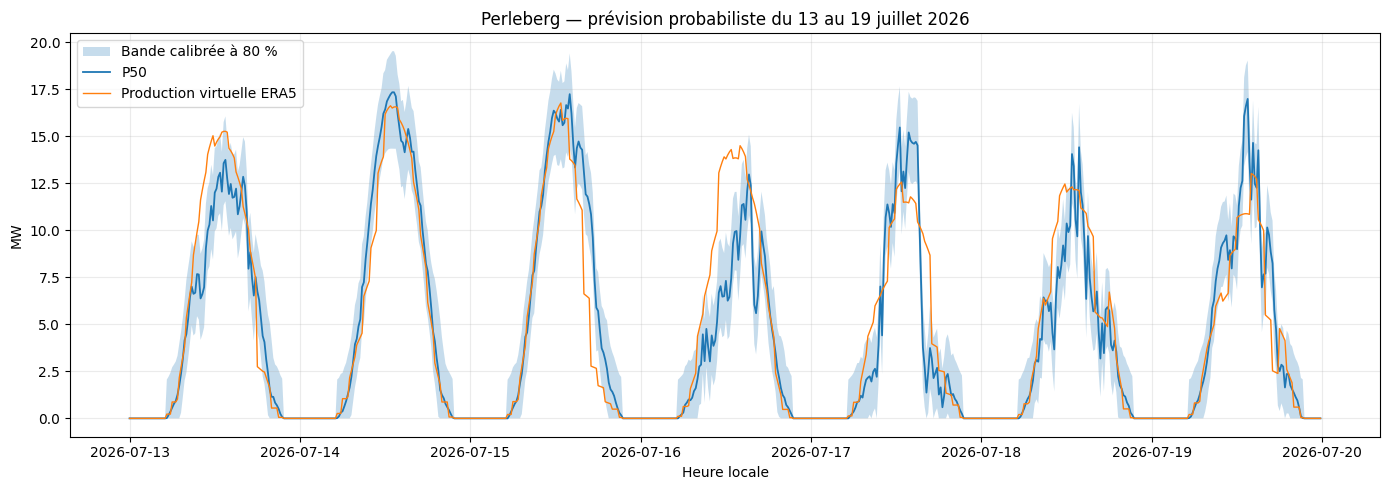

In [11]:
probability_view = test_quantiles.copy()
probability_view['observed_mw'] = y_test.to_numpy()
probability_view['timestamp_local'] = test_timestamps.dt.tz_convert(market_timezone).to_numpy()
week_start = pd.Timestamp('2026-07-13', tz=market_timezone)
week_end = week_start + pd.Timedelta(days=7)
week = probability_view.loc[
    probability_view['timestamp_local'].between(week_start, week_end, inclusive='left')
]
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(week['timestamp_local'], week['p10_mw'], week['p90_mw'], alpha=0.25, label='Bande calibrée à 80 %')
ax.plot(week['timestamp_local'], week['p50_mw'], linewidth=1.3, label='P50')
ax.plot(week['timestamp_local'], week['observed_mw'], linewidth=1.0, label='Production virtuelle ERA5')
ax.set(title='Perleberg — prévision probabiliste du 13 au 19 juillet 2026', xlabel='Heure locale', ylabel='MW')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

La semaine affichée permet de lire la prévision comme une plage de risque plutôt que comme une valeur certaine. Une observation hors bande n'est pas nécessairement une erreur de fonctionnement : un intervalle central à 80 % doit en laisser environ une sur cinq à l'extérieur sur un grand échantillon.

---
## Architecture d'explicabilité 

1. La **permutation groupée** mesure quelles familles sont nécessaires à la précision.
2. **TreeSHAP global** mesure l'intensité et le sens des effets appris par P50.
3. **TreeSHAP local** explique un quart d'heure précis avec des groupes lisibles par un trader.
4. La comparaison **P10/P50/P90** montre ce qui élargit ou resserre l'incertitude.

Les importances internes LightGBM fondées sur les splits ou le gain restent un outil de diagnostic technique ; elles ne servent pas ici à la conclusion métier.

## Mesure de l'importance globale par permutation groupée

Les variables corrélées sont déplacées ensemble : les quatre rayonnements forment par exemple un seul groupe. La hausse de MAE indique combien P50 dépend de chaque famille d'information, sans attribuer artificiellement tout le mérite à une seule mesure de rayonnement.

La permutation utilise les heures éclairées de juin, hors entraînement. Elle explique le modèle figé ; elle ne sert pas à modifier les features après le test.

,group,feature_count,mae_increase_mw,std_mw
0,Rayonnement,4,2.980467,0.063747
1,Calendrier et soleil,8,0.961236,0.019833
2,Météo hors rayonnement,7,0.013370,0.002698
3,Lags de production,2,0.001689,0.001218
4,Rollings de production,6,0.000666,0.000066


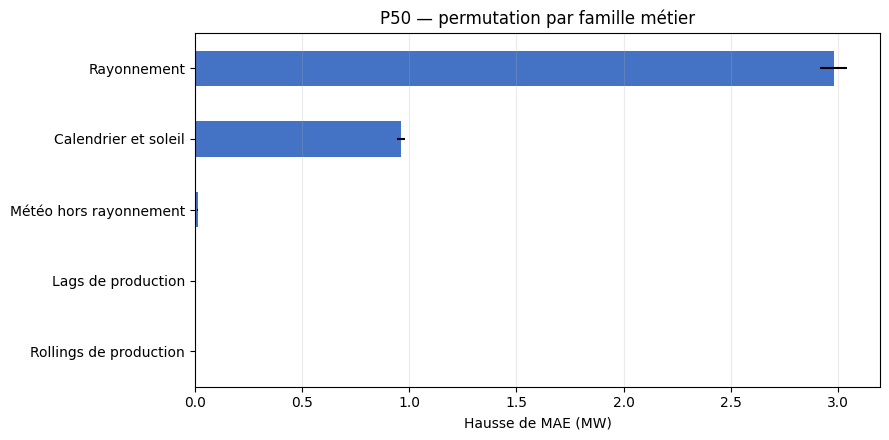

In [12]:
# Les groupes sont définis avec des noms lisibles par les utilisateurs métier.
business_feature_groups = {
    'Rayonnement': [
        'shortwave_radiation', 'direct_radiation',
        'diffuse_radiation', 'direct_normal_irradiance',
    ],
    'Météo hors rayonnement': [
        'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
        'cloud_cover', 'precipitation',
        'wind_direction_10m_sin', 'wind_direction_10m_cos',
    ],
    'Calendrier et soleil': [
        'local_time_sin', 'local_time_cos', 'day_of_year_sin',
        'day_of_year_cos', 'solar_elevation_deg',
        'solar_azimuth_sin', 'solar_azimuth_cos', 'is_day',
    ],
    'Lags de production': [
        'production_lag_48h_mw', 'production_lag_7d_mw',
    ],
    'Rollings de production': [
        column for column in predictor_columns if 'production_rolling_' in column
    ],
}

# Limiter le calcul aux heures éclairées et à un échantillon reproductible.
daylight_calibration_index = X_calibration.index[X_calibration['is_day'].astype(bool)]
importance_index = pd.Series(daylight_calibration_index).sample(
    n=min(4000, len(daylight_calibration_index)), random_state=42
).to_numpy()
importance_predictors = X_calibration.loc[importance_index]
importance_target = y_calibration.loc[importance_index]

grouped_importance = grouped_permutation_importance(
    quantile_models['p50_mw'],
    importance_predictors,
    importance_target,
    business_feature_groups,
    n_repeats=5,
    random_state=42,
)
display(grouped_importance)
ax = grouped_importance.sort_values('mae_increase_mw').plot.barh(
    x='group', y='mae_increase_mw', xerr='std_mw',
    figsize=(9, 4.5), legend=False, color='#4472C4',
)
ax.set(title='P50 — permutation par famille métier', xlabel='Hausse de MAE (MW)', ylabel='')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

Permuter les rayonnements augmente la MAE de **4,25 MW**, contre **1,54 MW** pour calendrier et soleil. Les lags apportent un signal plus faible (**0,0123 MW**) et les rollings un effet marginal (**0,0014 MW**). 

## Comprendre le comportement global avec TreeSHAP

LightGBM calcule ici les valeurs TreeSHAP natives. Leur valeur absolue moyenne mesure l'influence globale ; leur signe indique si une variable pousse la prévision brute vers le haut ou vers le bas. Les contributions regroupées évitent de surinterpréter le partage du mérite entre variables corrélées.

,group,mean_absolute_shap_mw
0,Rayonnement,4.237476
1,Calendrier et soleil,0.904839
2,Lags de production,0.105196
3,Météo hors rayonnement,0.079006
4,Rollings de production,0.001705


,feature,mean_absolute_shap_mw,group
5,shortwave_radiation,2.498108,Rayonnement
7,diffuse_radiation,1.495536,Rayonnement
17,solar_azimuth_cos,0.592138,Calendrier et soleil
8,direct_normal_irradiance,0.414687,Rayonnement
6,direct_radiation,0.372274,Rayonnement
15,solar_elevation_deg,0.297342,Calendrier et soleil
14,day_of_year_cos,0.121060,Calendrier et soleil
19,production_lag_48h_mw,0.105216,Lags de production
12,local_time_cos,0.087939,Calendrier et soleil
11,local_time_sin,0.082836,Calendrier et soleil


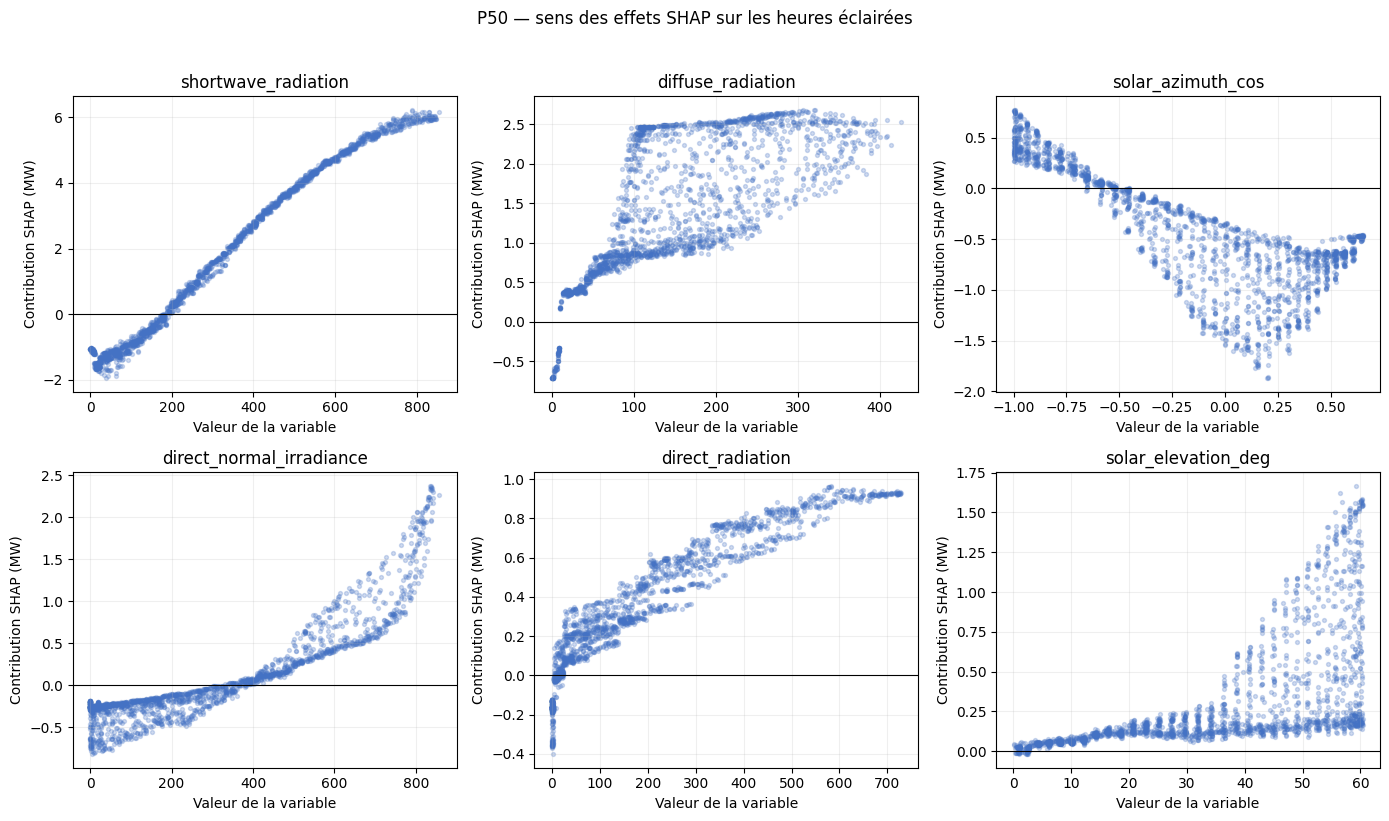

In [13]:
# Associer chaque prédicteur à une seule famille métier.
feature_to_business_group = {
    feature: group
    for group, features in business_feature_groups.items()
    for feature in features
}

# pred_contrib=True, appelé dans cette fonction, renvoie les valeurs TreeSHAP.
p50_shap_values, p50_shap_baseline = lightgbm_feature_contributions(
    quantile_models['p50_mw'], importance_predictors
)
grouped_p50_shap = group_feature_contributions(
    p50_shap_values, feature_to_business_group
)

# L'importance SHAP globale est la contribution absolue moyenne en MW.
global_shap = pd.DataFrame({
    'feature': predictor_columns,
    'mean_absolute_shap_mw': p50_shap_values.abs().mean().to_numpy(),
})
global_shap['group'] = global_shap['feature'].map(feature_to_business_group)
global_shap = global_shap.sort_values('mean_absolute_shap_mw', ascending=False)
global_group_shap = (
    grouped_p50_shap.abs().mean()
    .rename('mean_absolute_shap_mw')
    .sort_values(ascending=False)
    .rename_axis('group')
    .reset_index()
)
display(global_group_shap)
display(global_shap.head(12))

# Les six graphes suivants montrent le sens, et pas seulement l'importance.
top_effect_features = global_shap.head(6)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, feature in zip(axes.flat, top_effect_features):
    axis.scatter(
        importance_predictors[feature],
        p50_shap_values[feature],
        s=8, alpha=0.25, color='#4472C4',
    )
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set(title=feature, xlabel='Valeur de la variable', ylabel='Contribution SHAP (MW)')
    axis.grid(alpha=0.2)
fig.suptitle('P50 — sens des effets SHAP sur les heures éclairées', y=1.02)
plt.tight_layout()
plt.show()

Le rayonnement domine aussi TreeSHAP : **4,45 MW** de contribution absolue moyenne, contre **0,98 MW** pour calendrier et soleil. Le shortwave et le diffus arrivent en tête des variables individuelles. Ces résultats décrivent le modèle, pas une causalité physique.

## Explication d'une prévision précise

Choisisons le pic P50 du 19 juillet. Les contributions positives augmentent la prévision par rapport au niveau de base du modèle ; les contributions négatives la réduisent. La comparaison P10/P50/P90 montre aussi quelles familles élargissent ou resserrent l'incertitude. TreeSHAP explique les sorties brutes des trois modèles, avant bornage physique, remise en ordre des quantiles et calibration.

,example
timestamp_local,2026-07-19 13:30:00+02:00
observed_mw,10.871095
ordered_p10_mw,14.162151
ordered_p50_mw,16.980343
ordered_p90_mw,19.020586
raw_p10_mw,16.198372
raw_p50_mw,16.980343
raw_p90_mw,16.984366


,feature,shap_mw,group,absolute_shap_mw
5,shortwave_radiation,6.032084,Rayonnement,6.032084
7,diffuse_radiation,2.499139,Rayonnement,2.499139
8,direct_normal_irradiance,2.052219,Rayonnement,2.052219
15,solar_elevation_deg,1.591963,Calendrier et soleil,1.591963
6,direct_radiation,0.921186,Rayonnement,0.921186
17,solar_azimuth_cos,0.771396,Calendrier et soleil,0.771396
18,is_day,0.296696,Calendrier et soleil,0.296696
14,day_of_year_cos,-0.154367,Calendrier et soleil,0.154367
19,production_lag_48h_mw,0.121637,Lags de production,0.121637
0,temperature_2m,-0.108820,Météo hors rayonnement,0.108820


,P10,P50,P90,Effet sur largeur P90-P10
Météo hors rayonnement,-0.009105,0.003551,0.009316,0.018421
Rayonnement,7.403446,11.504629,13.026738,5.623292
Calendrier et soleil,6.061821,2.565134,1.085858,-4.975963
Lags de production,0.021699,0.122371,0.005611,-0.016088
Rollings de production,-0.000150,-0.000956,-0.001985,-0.001835


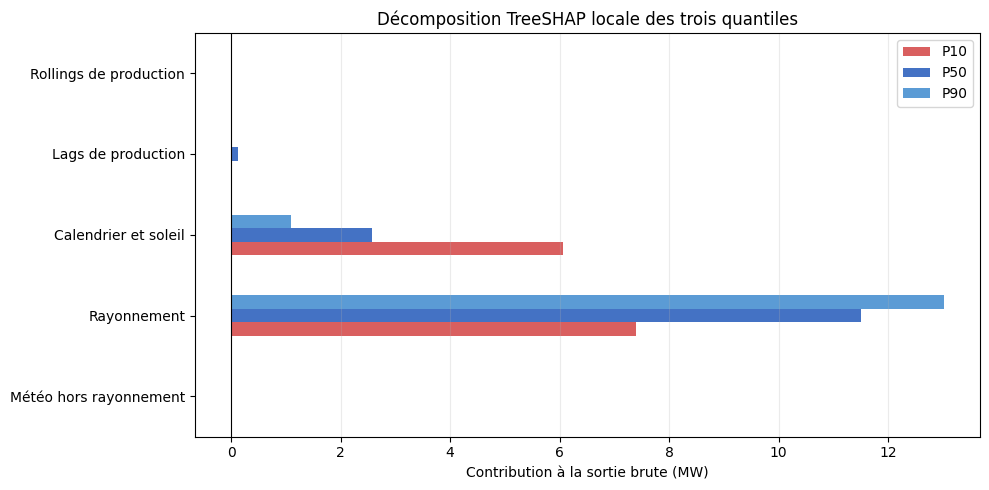

,contribution_to_raw_width_mw
Météo hors rayonnement,0.018421
Rayonnement,5.623292
Calendrier et soleil,-4.975963
Lags de production,-0.016088
Rollings de production,-0.001835
Niveau de base,0.138168


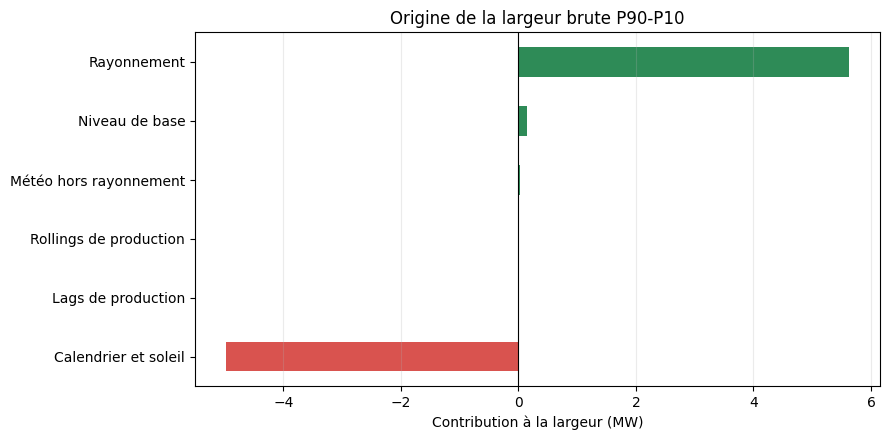

In [14]:
# Choisir un quart d'heure représentatif : le pic P50 du 19 juillet.
local_test_time = test_timestamps.dt.tz_convert(market_timezone)
example_day = pd.Timestamp('2026-07-19').date()
example_indices = test_timestamps.index[local_test_time.dt.date == example_day]
example_index = test_quantiles.loc[example_indices, 'p50_mw'].idxmax()
example_predictors = X_test.loc[[example_index]]

# Calculer une décomposition TreeSHAP pour chacun des trois modèles quantiles.
quantile_feature_shap = {}
quantile_group_shap = {}
quantile_baselines = {}
quantile_raw_predictions = {}
for quantile_name, quantile_model in quantile_models.items():
    feature_shap, shap_baseline = lightgbm_feature_contributions(
        quantile_model, example_predictors
    )
    grouped_shap = group_feature_contributions(
        feature_shap, feature_to_business_group
    )
    quantile_feature_shap[quantile_name] = feature_shap.iloc[0]
    quantile_group_shap[quantile_name] = grouped_shap.iloc[0]
    quantile_baselines[quantile_name] = shap_baseline.iloc[0]
    # Base + contributions reconstruit exactement la sortie brute LightGBM.
    quantile_raw_predictions[quantile_name] = (
        shap_baseline.iloc[0] + feature_shap.iloc[0].sum()
    )

p50_local_shap = pd.DataFrame({
    'feature': predictor_columns,
    'shap_mw': quantile_feature_shap['p50_mw'].to_numpy(),
})
p50_local_shap['group'] = p50_local_shap['feature'].map(feature_to_business_group)
p50_local_shap['absolute_shap_mw'] = p50_local_shap['shap_mw'].abs()

# Mettre côte à côte le forecast exploitable et les sorties brutes expliquées.
example_summary = pd.Series({
    'timestamp_local': local_test_time.loc[example_index],
    'observed_mw': y_test.loc[example_index],
    'ordered_p10_mw': test_quantiles.loc[example_index, 'p10_mw'],
    'ordered_p50_mw': test_quantiles.loc[example_index, 'p50_mw'],
    'ordered_p90_mw': test_quantiles.loc[example_index, 'p90_mw'],
    'raw_p10_mw': quantile_raw_predictions['p10_mw'],
    'raw_p50_mw': quantile_raw_predictions['p50_mw'],
    'raw_p90_mw': quantile_raw_predictions['p90_mw'],
}, name='example')
display(example_summary.to_frame())
display(p50_local_shap.sort_values('absolute_shap_mw', ascending=False).head(10))

quantile_group_table = pd.DataFrame(quantile_group_shap).rename(
    columns={'p10_mw': 'P10', 'p50_mw': 'P50', 'p90_mw': 'P90'}
)
quantile_group_table['Effet sur largeur P90-P10'] = (
    quantile_group_table['P90'] - quantile_group_table['P10']
)
display(quantile_group_table)

ax = quantile_group_table[['P10', 'P50', 'P90']].plot.barh(
    figsize=(10, 5), color=['#D95F5F', '#4472C4', '#5B9BD5']
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(
    title='Décomposition TreeSHAP locale des trois quantiles',
    xlabel='Contribution à la sortie brute (MW)', ylabel='',
)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

# Une valeur positive élargit localement P90-P10 ; une valeur négative la resserre.
width_decomposition = quantile_group_table['Effet sur largeur P90-P10'].copy()
width_decomposition.loc['Niveau de base'] = (
    quantile_baselines['p90_mw'] - quantile_baselines['p10_mw']
)
display(width_decomposition.rename('contribution_to_raw_width_mw').to_frame())
ax = width_decomposition.sort_values().plot.barh(
    figsize=(9, 4.5),
    color=['#D9534F' if value < 0 else '#2E8B57' for value in width_decomposition.sort_values()],
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Origine de la largeur brute P90-P10', xlabel='Contribution à la largeur (MW)', ylabel='')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

Le 19 juillet à 14 h, P50 prévoit **12,986 MW** pour **13,016 MW** de production virtuelle. La réalisation se trouve légèrement au-dessus de la borne calibrée P90 (**13,007 MW**).

Cet exemple présente aussi un croisement brut : P50 vaut 12,988 MW et P90 12,986 MW. Le tri modifie donc la médiane affichée. SHAP explique les sorties brutes, tandis que le tableau distingue les valeurs finales après correction et calibration.

## Vérification du biais horaire de P50

Une bonne moyenne globale peut masquer une sous-prévision du pic ou une sur-prévision du soir. La MAE et le biais sont donc regroupés par heure locale.

,mae_mw,bias_mw,rows
local_hour,,,
0,0.000000,0.000000,248
1,0.000000,0.000000,248
2,0.000000,0.000000,248
3,0.000000,0.000000,248
4,0.000000,0.000000,248
5,0.042991,-0.023600,248
6,0.206376,-0.094740,248
7,0.505996,-0.379589,248
8,1.078705,-0.431154,248


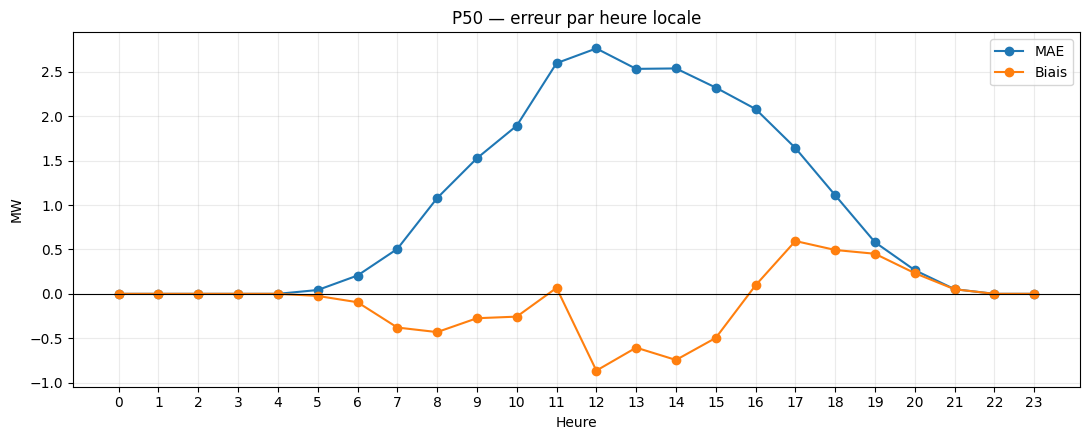

In [15]:
hourly_profile = hourly_error_profile(
    y_test, test_quantiles['p50_mw'], test_timestamps, market_timezone
)
display(hourly_profile)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(hourly_profile.index, hourly_profile['mae_mw'], marker='o', label='MAE')
ax.plot(hourly_profile.index, hourly_profile['bias_mw'], marker='o', label='Biais')
ax.axhline(0, color='black', linewidth=0.8)
ax.set(title='P50 — erreur par heure locale', xlabel='Heure', ylabel='MW')
ax.set_xticks(range(24))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


La MAE horaire culmine à **0,102 MW vers 13 h**. Le biais est légèrement positif le matin, puis négatif autour de midi ; son amplitude reste inférieure à **0,031 MW**. Les zéros nocturnes ne doivent pas masquer ces erreurs de jour.

Le modèle ponctuel est sélectionné par validation temporelle. Les trois quantiles reprennent la configuration du meilleur LightGBM. Pour les traders, P50 fournit le scénario central tandis que P10 et P90 rendent immédiatement visible le risque autour de ce scénario. Les explications décrivent le comportement du modèle, pas une causalité physique. La calibration et le test utilisent les forecasts météo J-1 réellement disponibles avant le cutoff.